In [1]:
import os
import pandas as pd
import plotnine as pln

# create fasta files from metadata

In [4]:
base_dir = '../data/ProteinGym_metadata/multiples'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    file_name = file.strip('.csv')

    with open(f"../data/ProteinGym_fasta/multiples/{file_name}.fasta", "w") as f:
        for _, row in df.iterrows():
            f.write(f">{row['mutant']}\n{row['mutated_sequence']}\n")


# count mutations in dataset

In [ ]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    df['#mutations'] = [len(x.split(':')) for x in df['mutant']]
    df.rename(columns={'mutant':'ID', 'DMS_score':'target'}, inplace=True)
    df.to_csv(os.path.join(base_dir, file), index=False)

df

## 

In [57]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    if file.strip('.csv') in l:
        print(f'File name: {file}')
        print(df['#mutations'].value_counts())
    

File name: RAD_ANTMA_Tsuboyama_2023_2CJJ.csv
#mutations
1    774
2    138
Name: count, dtype: int64
File name: PSAE_PICP2_Tsuboyama_2023_1PSE.csv
#mutations
1    1219
2     360
Name: count, dtype: int64
File name: THO1_YEAST_Tsuboyama_2023_2WQG.csv
#mutations
1    656
2    623
Name: count, dtype: int64
File name: RPC1_BP434_Tsuboyama_2023_1R69.csv
#mutations
1    1124
2     335
Name: count, dtype: int64
File name: TNKS2_HUMAN_Tsuboyama_2023_5JRT.csv
#mutations
1    1118
2     361
Name: count, dtype: int64


# Spliting data into singles and doubles (train/test)

In [47]:
def split_data(df):
    """
    This function splits a dataframe based on number of mutations into train and validation data.
    """
    # Split dataframe
    train_df = df[df["#mutations"]==1]
    val_df = df[df["#mutations"]>1]
   
    return train_df, val_df

In [60]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
   
    train, val = split_data(df)
    print(file)

    print(f"Train shape: {train.shape}")
    print(f"Val shape: {val.shape}")
    break
   

BBC1_YEAST_Tsuboyama_2023_1TG0.csv
Train shape: (1084, 5)
Val shape: (985, 5)


# Aditive model

In [10]:
import os
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from collections import defaultdict

class PositionAwareAdditiveModel:
    def __init__(self, mutation_col='mutation', score_col='score'):
        self.mutation_col = mutation_col
        self.score_col = score_col
        
        # Fallback storage layers
        self.single_mutant_map = {}
        self.position_avg_map = {}
        self.global_median = 0.0
        
    def _extract_position(self, mut_string):
        """Extracts the numeric position from a mutation string (e.g., 'M2D' -> '2')."""
        match = re.search(r'\d+', mut_string)
        return match.group(0) if match else None

    def data_split(self, df):
        """
        Splits the mixed dataset into singles (Train) and doubles (Test),
        and extracts multi-layer baseline metrics from the singles.
        """
    
        is_double = df[self.mutation_col].str.contains(':', na=False)
        train_df = df[~is_double].copy()
        test_df = df[is_double].copy()
        
        # Layer 1: Specific Mutation Lookup Map
        self.single_mutant_map = dict(zip(train_df[self.mutation_col], train_df[self.score_col]))
        
        # Layer 2: Position-Specific Average Map
        position_scores = defaultdict(list)
        for mut, score in self.single_mutant_map.items():
            pos = self._extract_position(mut)
            if pos:
                position_scores[pos].append(score)
        self.position_avg_map = {pos: np.mean(scores) for pos, scores in position_scores.items()}

        # Layer 3: Global Protein Median (Absolute fallback)
        if self.single_mutant_map:
            self.global_median = np.median(list(self.single_mutant_map.values()))
        else:
            self.global_median = 0.0
        
        return train_df, test_df

    def _get_single_score_with_fallback(self, mut):
        """Hierarchical lookup sequence: Exact Mutant -> Position Average -> Global Median"""
        # 1. Try exact match (e.g., M2D)
        if mut in self.single_mutant_map:
            return self.single_mutant_map[mut]
            
        # 2. Try position-based match (e.g., Position 2 average)
        pos = self._extract_position(mut)
        if pos in self.position_avg_map:
            return self.position_avg_map[pos]
        
        # 3. Final fallback: global median
        return self.global_median

    def predict(self, test_df):
        """
        Predicts double mutant scores by summing their constituent single mutant scores,
        utilizing position-based substitution to guarantee a prediction for every row.
        """
        predictions = []
        
        for mut_string in test_df[self.mutation_col]:
            parts = mut_string.split(':')
            
            if len(parts) == 2:
                mut1, mut2 = parts[0], parts[1]
                
                # Extract scores using the fallback hierarchy
                score1 = self._get_single_score_with_fallback(mut1)
                score2 = self._get_single_score_with_fallback(mut2)
                
                # Compute additive expectation
                predictions.append(score1 + score2)
                    
                
        return np.array(predictions)
    
    def evaluate(self, test_df, y_pred):
        """
        Evaluates the predictions across the complete, unbroken test array.
        """
        eval_df = test_df.copy()
        eval_df['predicted_score'] = y_pred
        
        y_true = eval_df[self.score_col].values
        y_pred_all = eval_df['predicted_score'].values
        
        # Standard regression metrics over the full matrix
        r2 = r2_score(y_true, y_pred_all)
        rho, _ = spearmanr(y_true, y_pred_all)
        mae = np.mean(np.abs(y_true - y_pred_all))

        res_dict = {
            "Dataset": None,
            "R2_score_test": r2,
            "MAE_score_test": mae,
            "rho_score_test": rho,
            }
        
        results = pd.DataFrame.from_dict(res_dict, orient='index').T.reset_index(drop=True)
        
        return eval_df, results

In [3]:
df = pd.read_csv('../data/ProteinGym_metadata/doubles/AMFR_HUMAN_Tsuboyama_2023_4G3O.csv')

# 1. Initialize the model
model = PositionAwareAdditiveModel(mutation_col='ID', score_col='target')

# 2. Automatically split your mixed dataset into singles and doubles
train_singles, test_doubles = model.data_split(df)

# 3. Generate predictions on the test set
y_pred = model.predict(test_doubles)

# 4. Evaluate the performance metrics
val_df, res_df = model.evaluate(test_doubles, y_pred)
res_df

,Dataset,R2_score_test,MAE_score_test,rho_score_test
0,NaN,-4.799327,2.020757,0.639884


In [87]:
base_dir = '../data/ProteinGym_metadata/doubles/'

cols = ['Dataset', 'R2_score_test']

model = PositionAwareAdditiveModel(mutation_col='ID', score_col='target')

res1 = pd.DataFrame()
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    train_singles, test_doubles = model.data_split(df)
    y_pred = model.predict(test_doubles)
    val_df, res_df = model.evaluate(test_doubles, y_pred)

    res_df['Dataset'] = file.strip('.csv')
    res1 = pd.concat([res1, res_df]).reset_index(drop=True)

res1 = res1[cols] 
res1['Model'] = 'Additive'
res1.head()

,Dataset,R2_score_test,Model
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,Additive
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,Additive
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,Additive
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,Additive
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,Additive


# load lassoCV results on sigles to doubles split

In [88]:
res2 = pd.DataFrame()
base_dir = '../experiments/doubles/esm2_650m/mut_split'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res2 = pd.concat([res2, res_df]).reset_index(drop=True)

res2 = res2[cols] 
res2['Model'] = 'Single to double' 
res2.head()

,Dataset,R2_score_test,Model
0,RD23A_HUMAN_Tsuboyama_2023_1IFY,0.587239,Single to double
1,SPTN1_CHICK_Tsuboyama_2023_1TUD,0.247770,Single to double
2,ODP2_GEOSE_Tsuboyama_2023_1W4G,0.495215,Single to double
3,HECD1_HUMAN_Tsuboyama_2023_3DKM,-0.244082,Single to double
4,SR43C_ARATH_Tsuboyama_2023_2N88,-0.182614,Single to double


In [89]:
res12 = res1.merge(res2, on='Dataset')
res12.head()

,Dataset,R2_score_test_x,Model_x,R2_score_test_y,Model_y
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,Additive,0.050238,Single to double
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,Additive,-9.228797,Single to double
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,Additive,0.034673,Single to double
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,Additive,-0.653195,Single to double
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,Additive,-0.988251,Single to double


In [111]:
res12.shape

(58, 5)

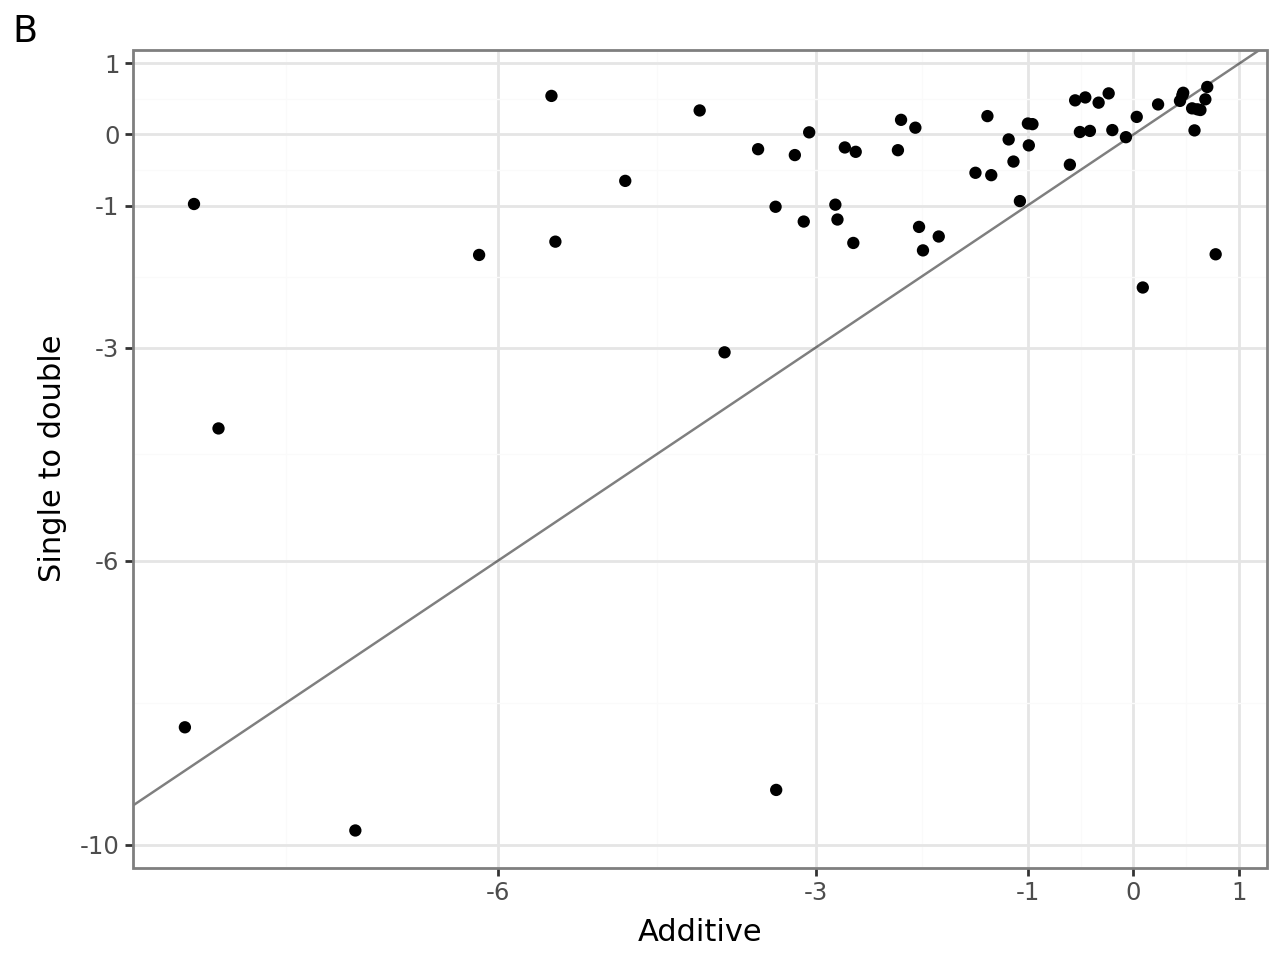

In [142]:
p2 = (
    pln.ggplot(res12, pln.aes(x='R2_score_test_x', y='R2_score_test_y'))
    + pln.geom_point()
    + pln.geom_abline(alpha=0.5)
    + pln.labs(
        x= 'Additive',
        y= 'Single to double',
        tag='B'
    )
    + pln.theme(
        legend_position='top',
        figure_size=(4,4*0.67))
    + pln.scale_y_continuous(breaks=[1, 0, -1, -3, -6, -10])
    + pln.scale_x_continuous(breaks=[1, 0, -1, -3, -6, -10])
    + pln.theme_bw()
)
p2

# load lassoCV results on pooled split

In [92]:
res3 = pd.DataFrame()
base_dir = '../experiments/doubles/esm2_650m/pooled'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res3 = pd.concat([res3, res_df]).reset_index(drop=True)

res3 = res3.groupby('Dataset', as_index=False).mean() 
res3 = res3[cols] 
res3['Model'] = 'Pooled' 
res3.head()

,Dataset,R2_score_test,Model
0,A4_HUMAN_Seuma_2022,0.740569,Pooled
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,0.849947,Pooled
2,BBC1_YEAST_Tsuboyama_2023_1TG0,0.821598,Pooled
3,BCHB_CHLTE_Tsuboyama_2023_2KRU,0.845168,Pooled
4,CATR_CHLRE_Tsuboyama_2023_2AMI,0.877959,Pooled


## merge results

In [100]:
#res123 = pd.concat([res1, res2, res3])

#res123.to_csv('../experiments/doubles/esm2_650m/pooled_SingleDoubleSplit_Additive_res.csv')
res123 = pd.read_csv('../experiments/doubles/esm2_650m/pooled_SingleDoubleSplit_Additive_res.csv')
res123

,Dataset,R2_score_test,Model
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,Additive
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,Additive
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,Additive
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,Additive
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,Additive
...,...,...,...
169,UBR5_HUMAN_Tsuboyama_2023_1I2T,0.718837,Pooled
170,VILI_CHICK_Tsuboyama_2023_1YU5,0.883670,Pooled
171,YAIA_ECOLI_Tsuboyama_2023_2KVT,0.808033,Pooled
172,YAP1_HUMAN_Araya_2012,0.514735,Pooled


In [ ]:
#res['R2_score_test'] = [-1 if x < -1 else x for x in res['R2_score_test']]

In [101]:
res123['Model'] = pd.Categorical(res123['Model'], categories=['Pooled', 'Single to double', 'Additive'])

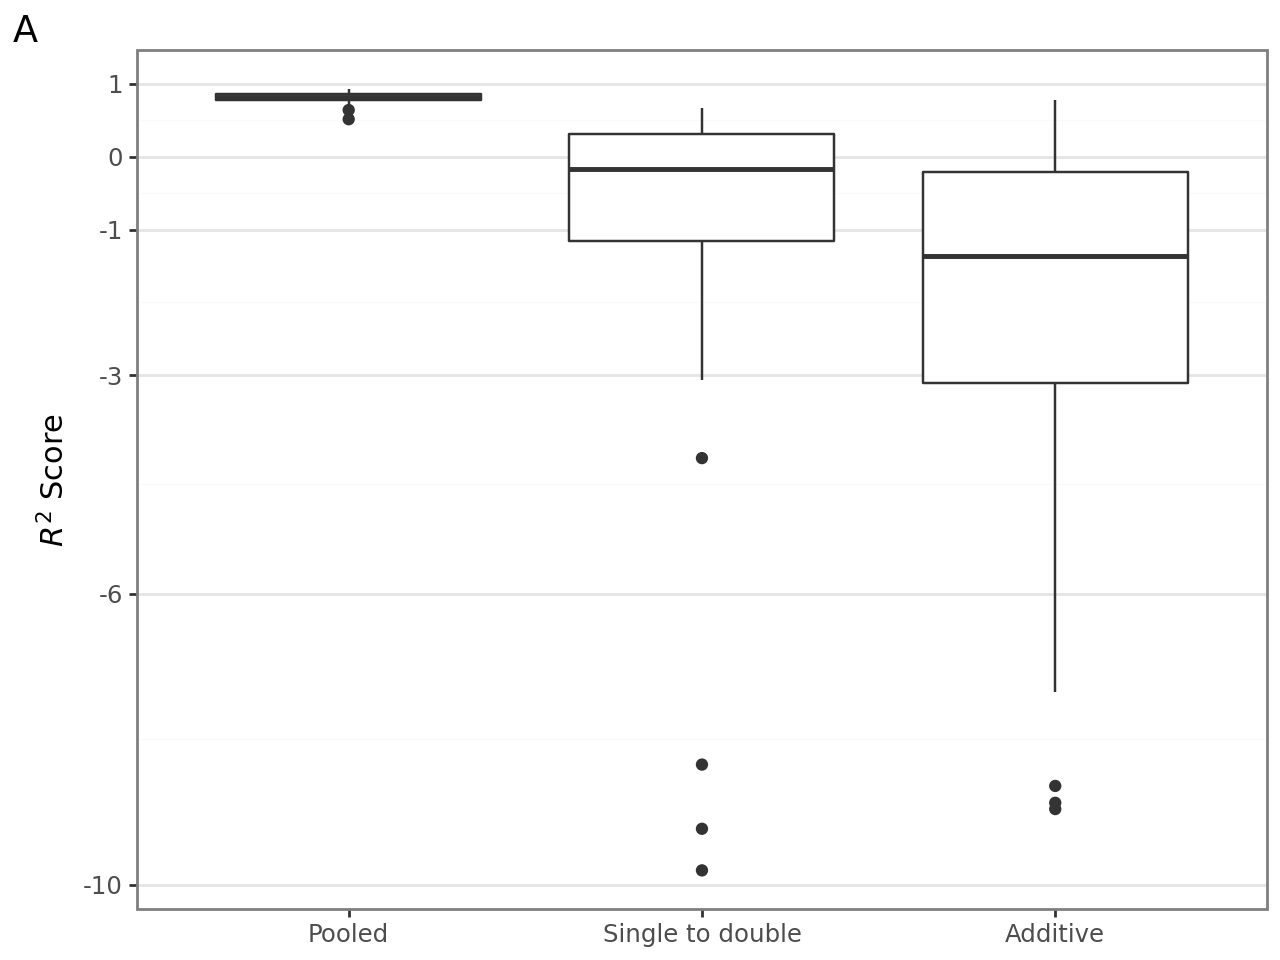

In [135]:
p1 = (
    pln.ggplot(res123, pln.aes(x='Model', y='R2_score_test'))
    + pln.geom_boxplot()
    + pln.labs(
        x='',
        y="$R^2$ Score",
        tag='A' 
    )
    + pln.scale_y_continuous(breaks=[1, 0, -1, -3, -6, -10])
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
                )
   
)
p1

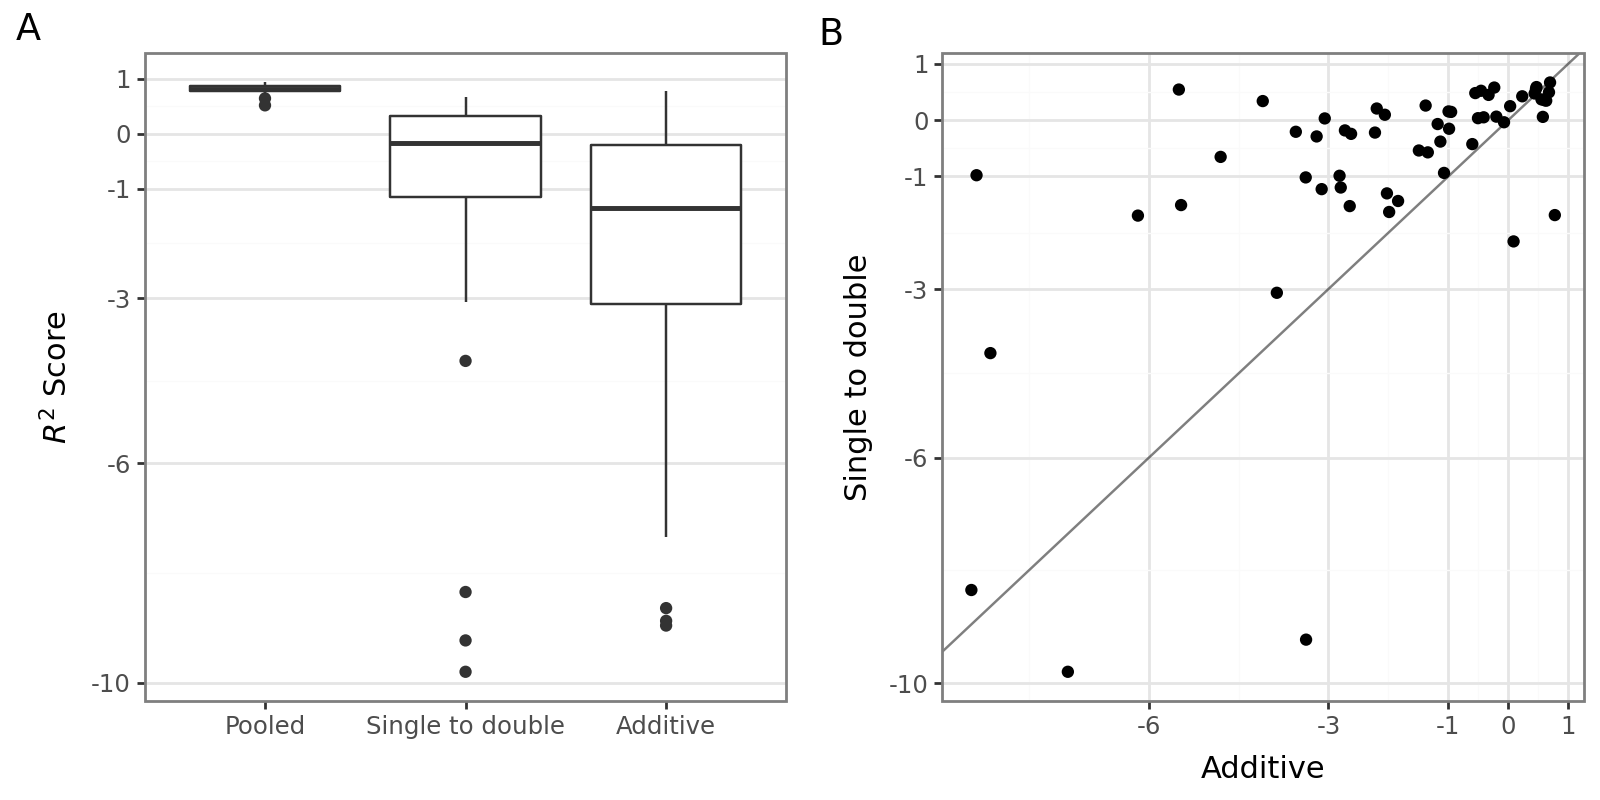

In [143]:
comp = (p1 | p2)
plot = comp + pln.theme(figure_size=(8, 4))
plot.save(filename='../experiments/figures/pooled_SingleDouble_Additive_esm2_650m.png', dpi=600)
plot